# Arch-PoC Comparison: Multi-dataset LOFO (04b)
**ST-LOFO cross-dataset generalisation across 12 model configs × 3 curve types**
- Each fold = one left-out dataset; metrics aggregated (mean ± std) across folds
- Axes: architecture (CGD / CGS / CCGD) × SC level (0–3) × curve type
- No regression head; classification accuracy only

In [1]:
# ── Cell 1: Imports & config ──────────────────────────────────────────────
import sys, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.metrics import accuracy_score

sys.path.insert(0, str(Path('..')))
sys.path.insert(0, str(Path('../utils')))
sys.path.insert(0, str(Path('../utils/model_training')))
import config

EXP_FOLDER  = '/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_multi_nc_subtract'
CURVE_TYPES = ['ori_curve', 'ori_curve_avg', 'ori_curve_wavelet_sym8']
CT_LABELS   = {
    'ori_curve':              'Original',
    'ori_curve_avg':          'Averaged',
    'ori_curve_wavelet_sym8': 'Wavelet (sym8)',
}

LOFO_KEYS = [
    'cgd_arch_poc_st_lofo',    'cgd_arch_poc_st_lofo_sc1',
    'cgd_arch_poc_st_lofo_sc2', 'cgd_arch_poc_st_lofo_sc3',
    'cgs_arch_poc_st_lofo',    'cgs_arch_poc_st_lofo_sc1',
    'cgs_arch_poc_st_lofo_sc2', 'cgs_arch_poc_st_lofo_sc3',
    'ccgd_arch_poc_st_lofo',   'ccgd_arch_poc_st_lofo_sc1',
    'ccgd_arch_poc_st_lofo_sc2', 'ccgd_arch_poc_st_lofo_sc3',
]

ARCH_COLORS = {'CGD': '#1565C0', 'CGS': '#E65100', 'CCGD': '#2E7D32'}
CT_COLORS   = {
    'ori_curve':              '#5C6BC0',
    'ori_curve_avg':          '#00897B',
    'ori_curve_wavelet_sym8': '#8D6E63',
}

def key_parts(k):
    k2 = k.replace('_arch_poc_st_lofo', '')
    if '_sc' in k2:
        arch = k2.split('_sc')[0].upper()
        sc   = int(k2.split('_sc')[-1])
    else:
        arch, sc = k2.upper(), 0
    return arch, sc

def key_label(k):
    arch, sc = key_parts(k)
    return f'{arch} SC{sc}'

print('Config OK')
print(f'Groups available: {list(config.CROSS_DATASET_GROUPS.keys())}')


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

Config OK
Groups available: ['init_oneplex_v6', 'init_oneplex_nc_subtract']


In [2]:
# ── Cell 2: Load all LOFO results → long-form DataFrame ───────────────────
cv_dir  = Path(EXP_FOLDER) / 'cross_dataset_cv'
records = []

for group_name in config.CROSS_DATASET_GROUPS:
    for curve_type in CURVE_TYPES:
        result_file = cv_dir / group_name / f'arch_poc_st_lofo_{curve_type}.joblib'
        if not result_file.exists():
            print(f'  [MISSING] {group_name} / {curve_type}')
            continue
        lofo_results = joblib.load(result_file)
        n_folds = 0
        for fold_label, fold_data in lofo_results.items():
            if not isinstance(fold_data, dict):
                continue
            entry = fold_data.get(None, {})
            if 'y_trues_' not in entry:
                continue
            n_folds += 1
            for m in LOFO_KEYS:
                pk  = f'y_preds_AC_{m}_'
                acc = (accuracy_score(entry['y_trues_'][0], entry[pk][0])
                       if pk in entry else np.nan)
                arch, sc = key_parts(m)
                records.append({
                    'group':      group_name,
                    'curve_type': curve_type,
                    'fold':       fold_label,
                    'model':      m,
                    'arch':       arch,
                    'sc':         sc,
                    'label':      key_label(m),
                    'acc':        acc,
                })
        print(f'  [OK] {group_name} / {curve_type}  ({n_folds} folds)')

df = pd.DataFrame(records)
available_cts = [ct for ct in CURVE_TYPES if ct in df['curve_type'].values]

print(f'\nLoaded {len(df)} rows  |  {df.fold.nunique()} total folds  |  {len(available_cts)} curve type(s)')
print(f'Available: {available_cts}')

print('\nTop-5 configs (mean acc across folds):')
overview = (df.groupby(['label','curve_type'])['acc']
              .agg(['mean','std'])
              .assign(mean_pct=lambda x: x['mean']*100, std_pct=lambda x: x['std']*100)
              .reset_index())
print(overview.sort_values('mean_pct', ascending=False).head(5)
      [['label','curve_type','mean_pct','std_pct']].round(3).to_string(index=False))

  [OK] init_oneplex_v6 / ori_curve  (4 folds)
  [OK] init_oneplex_v6 / ori_curve_avg  (4 folds)
  [OK] init_oneplex_v6 / ori_curve_wavelet_sym8  (4 folds)
  [MISSING] init_oneplex_nc_subtract / ori_curve
  [MISSING] init_oneplex_nc_subtract / ori_curve_avg
  [MISSING] init_oneplex_nc_subtract / ori_curve_wavelet_sym8

Loaded 144 rows  |  4 total folds  |  3 curve type(s)
Available: ['ori_curve', 'ori_curve_avg', 'ori_curve_wavelet_sym8']

Top-5 configs (mean acc across folds):
   label             curve_type  mean_pct  std_pct
CCGD SC3          ori_curve_avg    98.678    0.650
CCGD SC1          ori_curve_avg    98.655    0.806
 CGD SC2 ori_curve_wavelet_sym8    98.612    1.159
CCGD SC2          ori_curve_avg    98.600    1.142
CCGD SC2 ori_curve_wavelet_sym8    98.549    0.872


## 1 — Accuracy heatmap: model × curve type

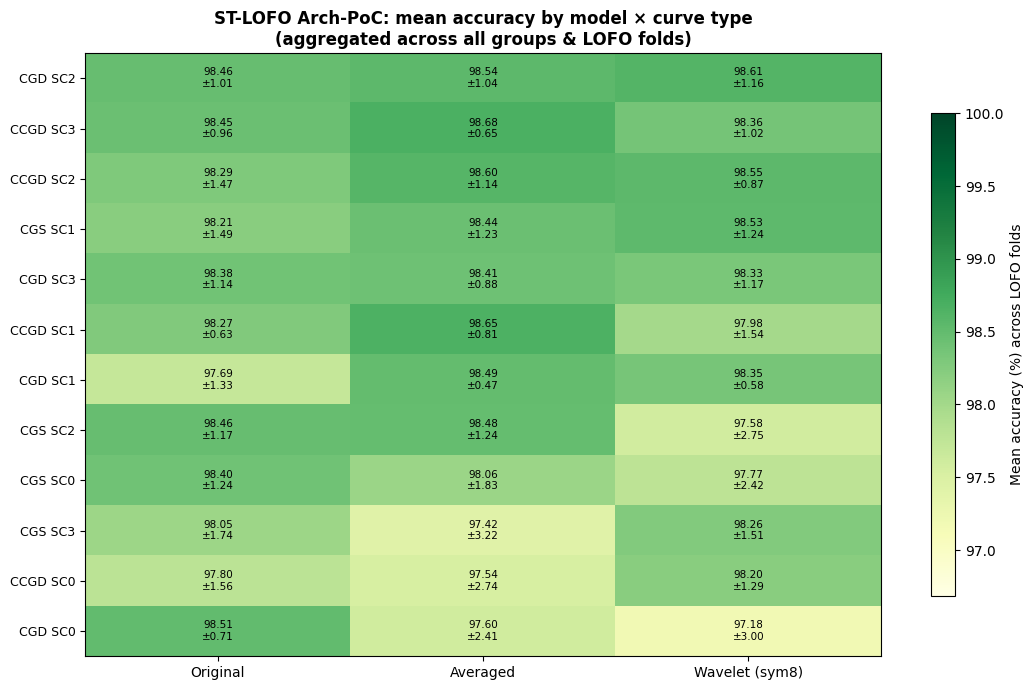

In [3]:
# ── Cell 3: Heatmap — 12 models × available curve types ───────────────────
agg = (df.groupby(['label','curve_type'])['acc']
         .agg(['mean','std'])
         .assign(mean_pct=lambda x: x['mean']*100, std_pct=lambda x: x['std']*100)
         .reset_index())

pivot_mean = agg.pivot(index='label', columns='curve_type', values='mean_pct').reindex(columns=available_cts)
pivot_std  = agg.pivot(index='label', columns='curve_type', values='std_pct').reindex(columns=available_cts)
row_order  = pivot_mean.mean(axis=1).sort_values(ascending=False).index
pivot_mean = pivot_mean.loc[row_order]
pivot_std  = pivot_std.loc[row_order]

n_cols = len(available_cts)
fig, ax = plt.subplots(figsize=(max(5, 3 * n_cols + 2), 7))
finite_vals = pivot_mean.values[np.isfinite(pivot_mean.values)]
vmin = max(90.0, float(finite_vals.min()) - 0.5) if len(finite_vals) else 90.0
im = ax.imshow(pivot_mean.values, aspect='auto', cmap='YlGn', vmin=vmin, vmax=100)
ax.set_xticks(range(n_cols))
ax.set_xticklabels([CT_LABELS[c] for c in available_cts], fontsize=10)
ax.set_yticks(range(len(pivot_mean.index)))
ax.set_yticklabels(pivot_mean.index, fontsize=9)
for i in range(pivot_mean.shape[0]):
    for j in range(pivot_mean.shape[1]):
        v = pivot_mean.values[i, j]
        s = pivot_std.values[i, j]
        if not np.isnan(v):
            txt  = f'{v:.2f}\n±{s:.2f}' if not np.isnan(s) else f'{v:.2f}'
            dark = v < 99.2
            ax.text(j, i, txt, ha='center', va='center', fontsize=7.5,
                    color='black' if dark else 'white')
plt.colorbar(im, ax=ax, shrink=0.8, label='Mean accuracy (%) across LOFO folds')
ax.set_title('ST-LOFO Arch-PoC: mean accuracy by model × curve type\n'
             '(aggregated across all groups & LOFO folds)', fontweight='bold')
plt.tight_layout()
plt.show()

## 2 — Mean accuracy by architecture & SC level

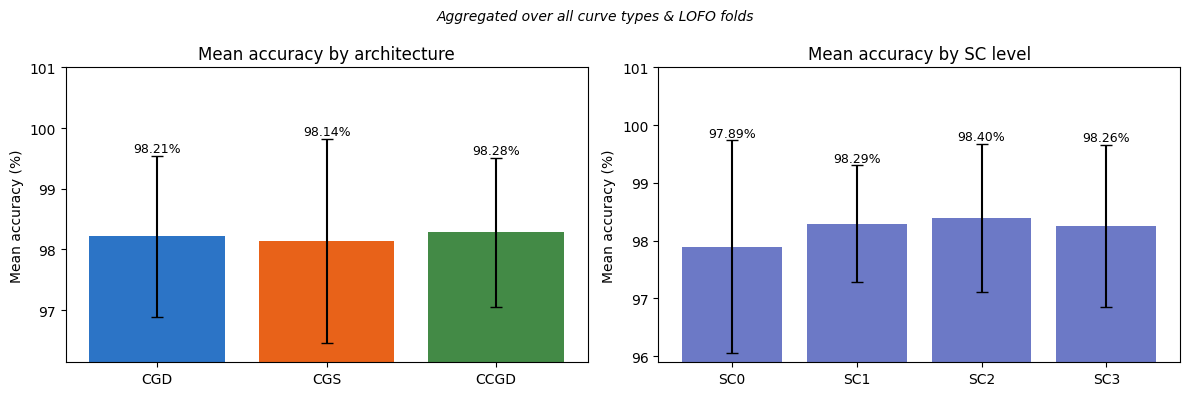

In [4]:
# ── Cell 4: Arch & SC bars — collapsed over curve types and folds ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

arch_agg = df.groupby('arch')['acc'].agg(['mean','std']).reindex(['CGD','CGS','CCGD']) * 100
ax = axes[0]
ax.bar(arch_agg.index, arch_agg['mean'],
       yerr=arch_agg['std'], capsize=4,
       color=[ARCH_COLORS[a] for a in arch_agg.index], alpha=0.9)
for i, (arch, row) in enumerate(arch_agg.iterrows()):
    ax.text(i, row['mean'] + row['std'] + 0.06, f"{row['mean']:.2f}%",
            ha='center', fontsize=9)
lo = max(90.0, arch_agg['mean'].min() - 2)
ax.set_ylim(lo, min(101, arch_agg['mean'].max() + arch_agg['std'].max() + 1.5))
ax.set_title('Mean accuracy by architecture')
ax.set_ylabel('Mean accuracy (%)')

sc_agg = df.groupby('sc')['acc'].agg(['mean','std']) * 100
ax2 = axes[1]
ax2.bar([f'SC{s}' for s in sc_agg.index], sc_agg['mean'],
        yerr=sc_agg['std'], capsize=4, color='#5C6BC0', alpha=0.9)
for i, (sc, row) in enumerate(sc_agg.iterrows()):
    ax2.text(i, row['mean'] + row['std'] + 0.06, f"{row['mean']:.2f}%",
             ha='center', fontsize=9)
lo2 = max(90.0, sc_agg['mean'].min() - 2)
ax2.set_ylim(lo2, min(101, sc_agg['mean'].max() + sc_agg['std'].max() + 1.5))
ax2.set_title('Mean accuracy by SC level')
ax2.set_ylabel('Mean accuracy (%)')

plt.suptitle('Aggregated over all curve types & LOFO folds', fontsize=10, style='italic')
plt.tight_layout()
plt.show()

## 3 — Curve-type effect on architecture & SC level

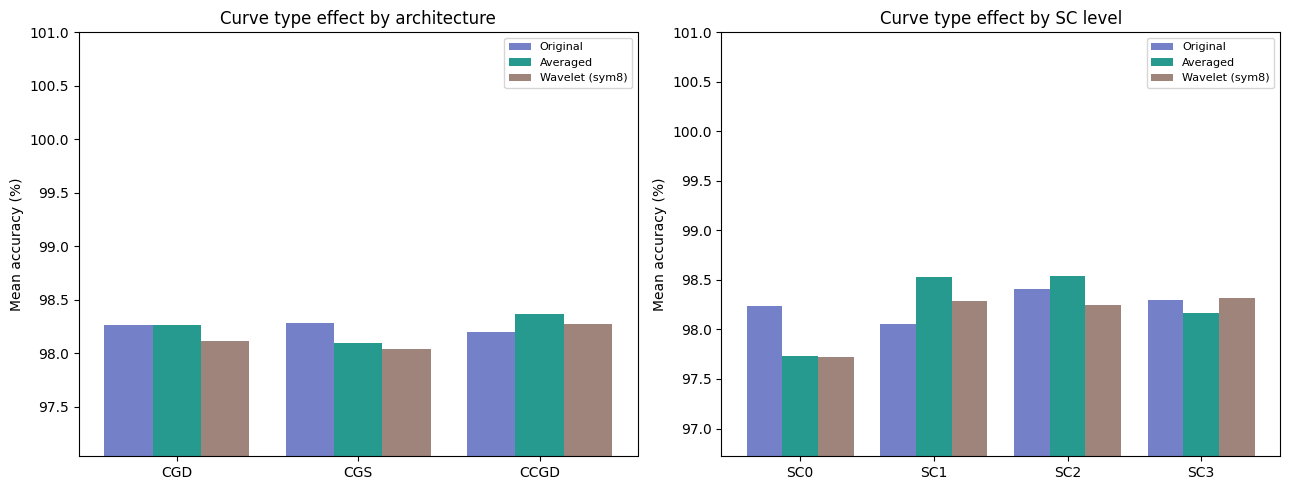

In [5]:
# ── Cell 5: Grouped bars — curve type × arch and curve type × SC ──────────
if len(available_cts) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    n = len(available_cts)
    w = 0.8 / n

    # Left: architecture × curve type
    ax = axes[0]
    x3 = np.arange(3)
    for i, ct in enumerate(available_cts):
        sub = (df[df['curve_type'] == ct]
               .groupby('arch')['acc'].mean()
               .reindex(['CGD','CGS','CCGD']) * 100)
        offset = (i - (n - 1) / 2) * w
        ax.bar(x3 + offset, sub.values, w,
               label=CT_LABELS[ct], color=CT_COLORS[ct], alpha=0.85)
    ax.set_xticks(x3)
    ax.set_xticklabels(['CGD','CGS','CCGD'])
    ax.set_ylabel('Mean accuracy (%)')
    ax.set_title('Curve type effect by architecture')
    ax.legend(fontsize=8)
    lo = max(90.0, df.groupby(['arch','curve_type'])['acc'].mean().min() * 100 - 1)
    ax.set_ylim(lo, 101)

    # Right: SC level × curve type
    ax2 = axes[1]
    x4  = np.arange(4)
    for i, ct in enumerate(available_cts):
        sub = (df[df['curve_type'] == ct]
               .groupby('sc')['acc'].mean() * 100)
        offset = (i - (n - 1) / 2) * w
        ax2.bar(x4 + offset, sub.values, w,
                label=CT_LABELS[ct], color=CT_COLORS[ct], alpha=0.85)
    ax2.set_xticks(x4)
    ax2.set_xticklabels(['SC0','SC1','SC2','SC3'])
    ax2.set_ylabel('Mean accuracy (%)')
    ax2.set_title('Curve type effect by SC level')
    ax2.legend(fontsize=8)
    lo2 = max(90.0, df.groupby(['sc','curve_type'])['acc'].mean().min() * 100 - 1)
    ax2.set_ylim(lo2, 101)

    plt.tight_layout()
    plt.show()
else:
    print('Only one curve type available — skipping grouped bar chart.')
    print('Run ori_curve_avg / wavelet jobs to see the cross-curve comparison.')

## 4 — Summary & leaderboard

In [6]:
# ── Cell 6: Summary ───────────────────────────────────────────────────────
print('='*72)
print('Best model per curve type  (mean acc across LOFO folds)')
print('='*72)
for ct in available_cts:
    sub  = df[df['curve_type'] == ct].groupby('label')['acc']
    mean = sub.mean()
    std  = sub.std()
    best = mean.idxmax()
    n_f  = df[(df['curve_type'] == ct) & (df['label'] == best)].fold.nunique()
    print(f"\n  {CT_LABELS[ct]:<18}  best = {best:<12}  "
          f"mean={mean[best]*100:.3f}%  std={std[best]*100:.3f}%  folds={n_f}")

print()
overall = df.groupby('label')['acc'].mean()
best_overall = overall.idxmax()
print(f'Overall best (collapsed over curve_types & folds): {best_overall}  '
      f'({overall[best_overall]*100:.3f}%)')
print()
print('All 12 models ranked (across all curve_types & folds):')
ranked = (
    df.groupby(['label','arch','sc'])['acc']
      .agg(['mean','std','count'])
      .assign(mean_pct=lambda x: x['mean']*100, std_pct=lambda x: x['std']*100)
      .sort_values('mean_pct', ascending=False)
      .reset_index()
     [['label','arch','sc','mean_pct','std_pct','count']]
      .rename(columns={'mean_pct': 'mean %', 'std_pct': 'std %', 'count': 'n_obs'})
)
print(ranked.round(3).to_string(index=False))

Best model per curve type  (mean acc across LOFO folds)

  Original            best = CGD SC0       mean=98.505%  std=0.706%  folds=4

  Averaged            best = CCGD SC3      mean=98.678%  std=0.650%  folds=4

  Wavelet (sym8)      best = CGD SC2       mean=98.612%  std=1.159%  folds=4

Overall best (collapsed over curve_types & folds): CGD SC2  (98.539%)

All 12 models ranked (across all curve_types & folds):
   label arch  sc  mean %  std %  n_obs
 CGD SC2  CGD   2  98.539  0.972     12
CCGD SC3 CCGD   3  98.495  0.819     12
CCGD SC2 CCGD   2  98.480  1.081     12
 CGS SC1  CGS   1  98.394  1.207     12
 CGD SC3  CGD   3  98.375  0.971     12
CCGD SC1 CCGD   1  98.301  1.009     12
 CGD SC1  CGD   1  98.178  0.875     12
 CGS SC2  CGS   2  98.173  1.743     12
 CGS SC0  CGS   0  98.077  1.732     12
 CGS SC3  CGS   3  97.910  2.104     12
CCGD SC0 CCGD   0  97.844  1.804     12
 CGD SC0  CGD   0  97.763  2.122     12


In [8]:
overview.sort_values('mean_pct', ascending=False)

,label,curve_type,mean,std,mean_pct,std_pct
10,CCGD SC3,ori_curve_avg,0.986785,0.006504,98.678490,0.650429
4,CCGD SC1,ori_curve_avg,0.986549,0.008061,98.654899,0.806131
20,CGD SC2,ori_curve_wavelet_sym8,0.986123,0.011589,98.612300,1.158917
7,CCGD SC2,ori_curve_avg,0.985997,0.011421,98.599662,1.142053
8,CCGD SC2,ori_curve_wavelet_sym8,0.985492,0.008724,98.549177,0.872395
19,CGD SC2,ori_curve_avg,0.985415,0.010424,98.541550,1.042385
29,CGS SC1,ori_curve_wavelet_sym8,0.985333,0.012391,98.533301,1.239075
12,CGD SC0,ori_curve,0.985055,0.007061,98.505457,0.706075
16,CGD SC1,ori_curve_avg,0.984885,0.004736,98.488547,0.473585
31,CGS SC2,ori_curve_avg,0.984754,0.012371,98.475389,1.237062
